# Zadanie domowe - EDA Danych dotyczących Irysów

* Twoim zadaniem jest wykonanie analizy danych zawartych w załączonym pliku CSV (`25__iris.csv`).
* Plik znajduje się pod video. Pamiętaj, żeby wrzucić plik do tego samego folderu, w którym znajduje się ten notebook.
* Wykorzystaj nowo nabytą wiedzę z biblioteki `Pandas`
* Jeżeli jest taka konieczność posiłkuj się [code explainerem](https://codeexplainer.imprv.ai/) lub / i [data chatterem](https://datachatter.imprv.ai/) (który również te dane ma dostępne).
* Prześlij na discordzie notebook z rozwiązaniem (`#modul-4-zad1`)
* Pamiętaj:

1. Nie spiesz się
2. Potraktuj zadanie domowe jak prawdziwy projekt
3. Dodawaj opisy, obserwacje, wnioski
4. Dodaj wizualizacje
5. Dodaj konkluzję i wnioski końcowe

Powodzenia!!! I mega zabawy!

## O Danych

Zbiór danych zawiera informacje o trzech gatunkach irysów: Iris setosa, Iris versicolor, i Iris virginica.

Dane obejmują pomiary czterech cech: długość i szerokość działki kielicha oraz długość i szerokość płatka.

Każdy wiersz w zbiorze danych reprezentuje pojedynczy kwiat, a wartości pomiarów są podane w centymetrach.

Zbiór składa się z 150 próbek, po 50 dla każdego gatunku, i jest szeroko stosowany jako podstawowy zbiór danych do
testowania algorytmów klasyfikacji oraz w nauce o danych i uczeniu maszynowym.

Kolumny:
* **długość kielicha (sepal length)** - Długość kielicha w cm
* **szerokość kielicha (sepal width)** - Szerokość kielicha w cm
* **długość płatka (petal length)** - Długość płatka w cm
* **szerokość płatka (petal width)** - Szerokość płatka w cm
* **klasa (class)** - Klasa irysa (setosa, versicolor, virginica)

## Prezentacja obiektów analizy ##

![Opis obrazka](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*YYiQed4kj_EZ2qfg_imDWA.png)

***Iris setosa*** to niska lecz bardzo urokliwa odmiana kosaćca. Dorasta do 30 centymetrów wysokości i tworzy kępy o podobnej szerokości. Kwiat dość ciekawy pojawia się w czerwcu. Płatki fioletowe z wyraźnym żyłkowaniem. Jest łatwy w uprawie, najlepiej pasuje mu gleba żyzna próchnicza. Lubi stanowisko słoneczne, da sobie radę w półcieniu ale kwitnie będzie mniej obfite. Jest w pełni mrozoodporny.

***Iris versicolor*** to rzadko spotykana odmiana kosaćca, dorastająca docelowo do około 70 cm wysokości. Jej młode pędy mają niezwykle dekoracyjny, fioletowy kolor. Ma niebieskie kwiatostany i kwitnie na przełomie maja i czerwca. Roślina tworzy okazałe kępy. Najlepiej rośnie w glebie żyznej i wilgotnej. Najpiękniej prezentuje się nad brzegami oczek wodnych oraz w towarzystwie piwoni. Warto go sadzić w miejscach wypoczynkowych, ponieważ roślina przyciąga motyle. Jest całkowicie odporna na mróz w naszym klimacie

***Iris versicolor*** to rzadko spotykana odmiana kosaćca, dorastająca docelowo do około 70 cm wysokości. Jej młode pędy mają niezwykle dekoracyjny, fioletowy kolor. Ma niebieskie kwiatostany i kwitnie na przełomie maja i czerwca. Roślina tworzy okazałe kępy. Najlepiej rośnie w glebie żyznej i wilgotnej. Najpiękniej prezentuje się nad brzegami oczek wodnych oraz w towarzystwie piwoni. Warto go sadzić w miejscach wypoczynkowych, ponieważ roślina przyciąga motyle. Jest całkowicie odporna na mróz w naszym klimacie

In [11]:
import pandas as pd

**Wczytujemy dane**

In [12]:
df = pd.read_csv('25__iris.csv', sep=",")
df

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


**Sprawdzamy brakujące wartości w zbiorze danych**

In [13]:
missing_values = df.isnull().sum()
print("Liczba brakujących wartości w każdej kolumnie:")
print(missing_values)


Liczba brakujących wartości w każdej kolumnie:
długość kielicha (sepal length)     0
szerokość kielicha (sepal width)    0
długość płatka (petal length)       0
szerokość płatka (petal width)      0
klasa (class)                       0
dtype: int64


**Procent brakujących wartości**

In [14]:
percent_missing = df.isnull().mean() * 100
print("\nProcent brakujących wartości w każdej kolumnie:")
print(percent_missing)


Procent brakujących wartości w każdej kolumnie:
długość kielicha (sepal length)     0.0
szerokość kielicha (sepal width)    0.0
długość płatka (petal length)       0.0
szerokość płatka (petal width)      0.0
klasa (class)                       0.0
dtype: float64


**Wnioski**

In [15]:
if missing_values.sum() == 0:
    print("\nBrak brakujących wartości w zbiorze danych.")
else:
    print("\nW zbiorze danych występują brakujące wartości. Zaleca się ich uzupełnienie lub usunięcie.")



Brak brakujących wartości w zbiorze danych.


## Analiza pojedynczych zmiennych

Analiza pojedynczych zmiennych (analiza uniwariancyjna) polega na zbadaniu rozkładu każdej cechy osobno. Pozwala to zrozumieć, jak rozkładają się wartości danej zmiennej, czy występują wartości odstające oraz jaka jest ich ogólna charakterystyka. W tej sekcji przeanalizujemy każdą z cech liczbowych w zbiorze danych irysów.

**Statystyki opisowe dla cech liczbowych**

In [37]:
df.describe()

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Histogramy cech liczbowych**

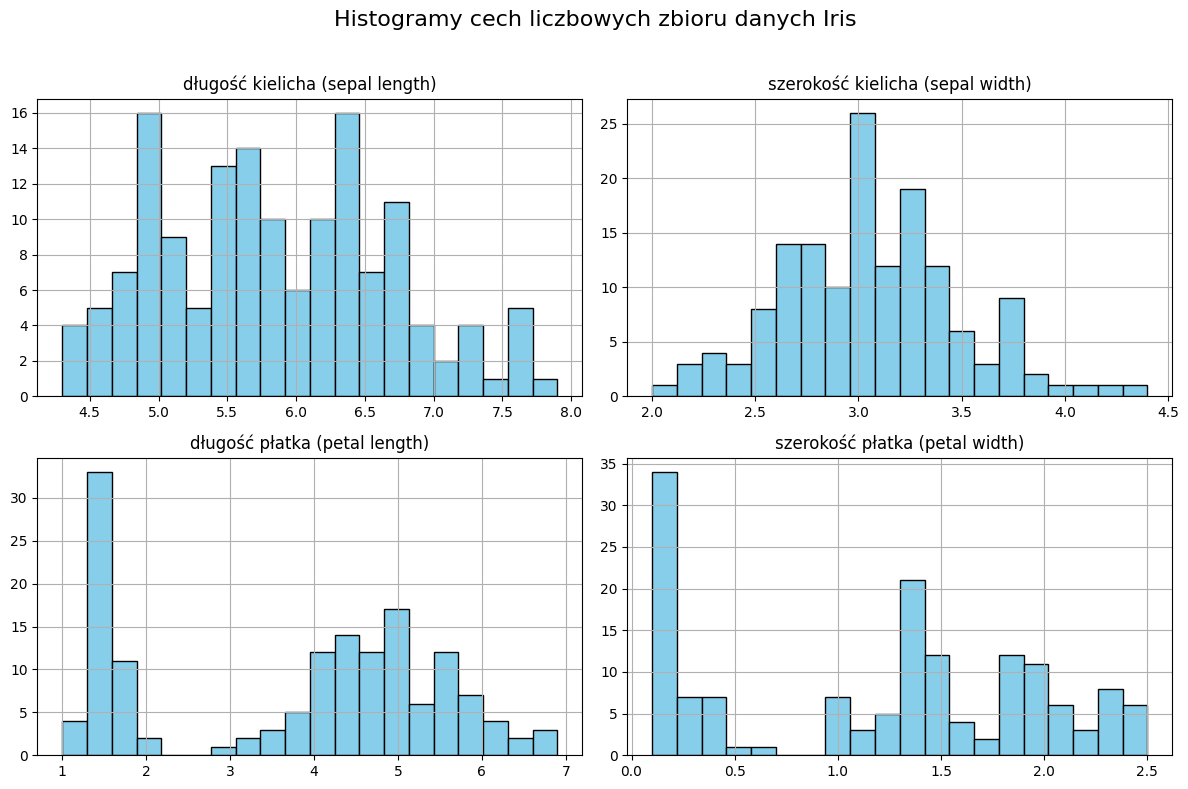

In [38]:
import matplotlib.pyplot as plt

df.hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histogramy cech liczbowych zbioru danych Iris', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Komentarz:**

Histogramy powyżej przedstawiają rozkład wartości dla każdej z cech liczbowych w zbiorze danych Iris. Możemy zaobserwować, że niektóre cechy mają rozkład bardziej symetryczny, inne są skośne. Warto zwrócić uwagę na ewentualne wartości odstające oraz różnice w rozkładach pomiędzy cechami. Taka analiza pozwala lepiej zrozumieć strukturę danych przed dalszymi etapami eksploracji.

## Analiza relacji między zmiennymi

W tej sekcji sprawdzimy, jak poszczególne cechy zbioru danych są ze sobą powiązane. Analiza relacji między zmiennymi pozwala zidentyfikować zależności liniowe, współwystępowanie cech oraz potencjalne korelacje, które mogą być istotne w dalszej analizie lub modelowaniu.

**Macierz korelacji cech liczbowych**

In [40]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width)
długość kielicha (sepal length),1.000000,-0.109369,0.871754,0.817954
szerokość kielicha (sepal width),-0.109369,1.000000,-0.420516,-0.356544
długość płatka (petal length),0.871754,-0.420516,1.000000,0.962757
szerokość płatka (petal width),0.817954,-0.356544,0.962757,1.000000


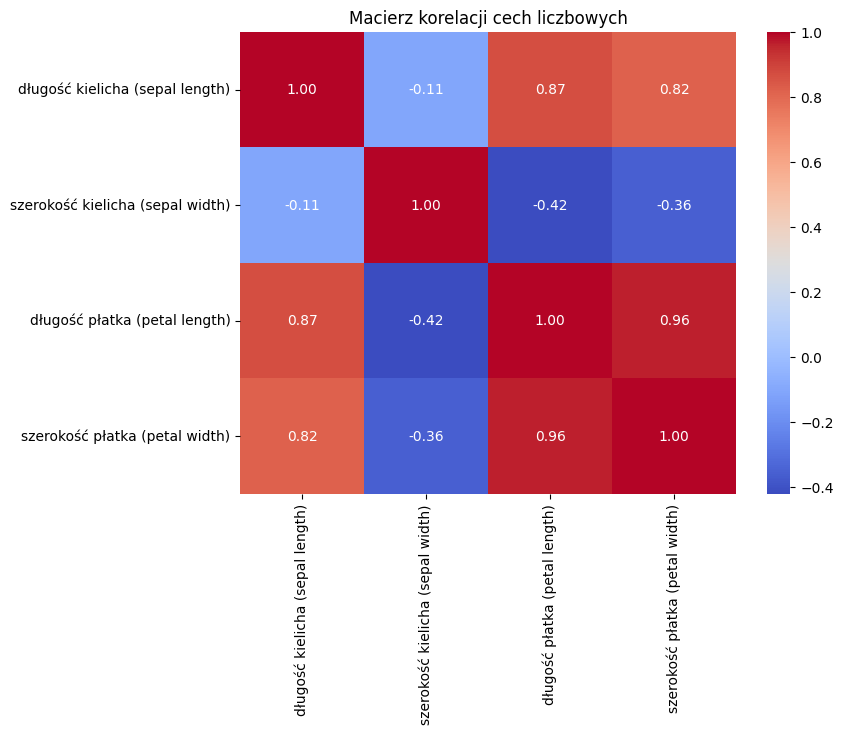

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech liczbowych')
plt.show()

**Wizualizacja relacji między cechami (pairplot)**

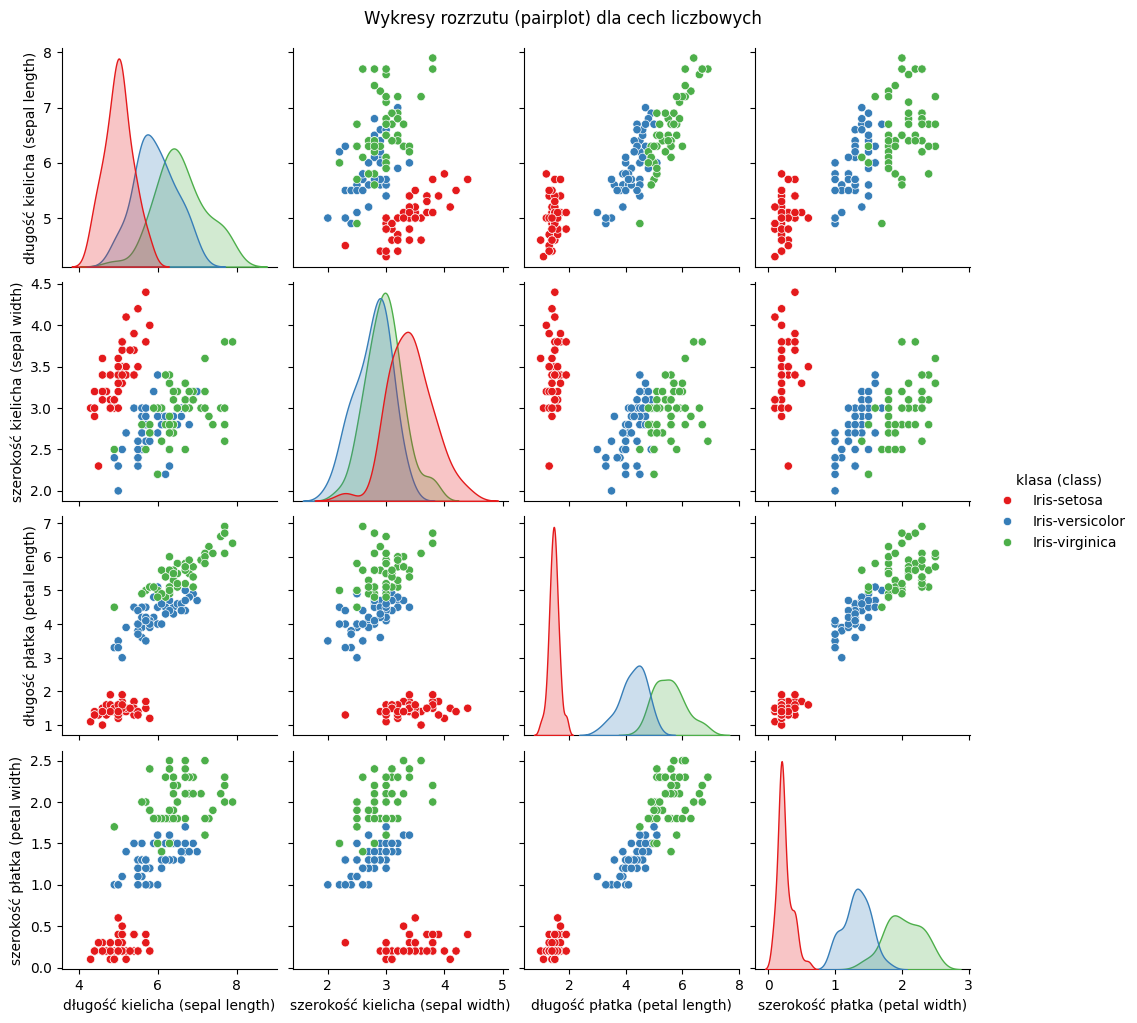

In [42]:
sns.pairplot(df, hue='klasa (class)', diag_kind='kde', palette='Set1')
plt.suptitle('Wykresy rozrzutu (pairplot) dla cech liczbowych', y=1.02)
plt.show()

**Komentarz:**

Na podstawie macierzy korelacji oraz wykresów rozrzutu można zauważyć, że niektóre cechy są silnie skorelowane (np. długość i szerokość płatka). Pairplot pozwala także zaobserwować, jak poszczególne klasy irysów rozdzielają się względem cech, co może być pomocne przy budowie modeli klasyfikacyjnych.

## Analiza wartości odstających

W tej sekcji sprawdzimy, czy w zbiorze danych występują wartości odstające (outliers) w cechach liczbowych. Wartości odstające mogą mieć istotny wpływ na analizę i modele predykcyjne, dlatego warto je zidentyfikować i rozważyć sposób postępowania z nimi.

**Wizualizacja wartości odstających za pomocą wykresów pudełkowych (boxplot)**

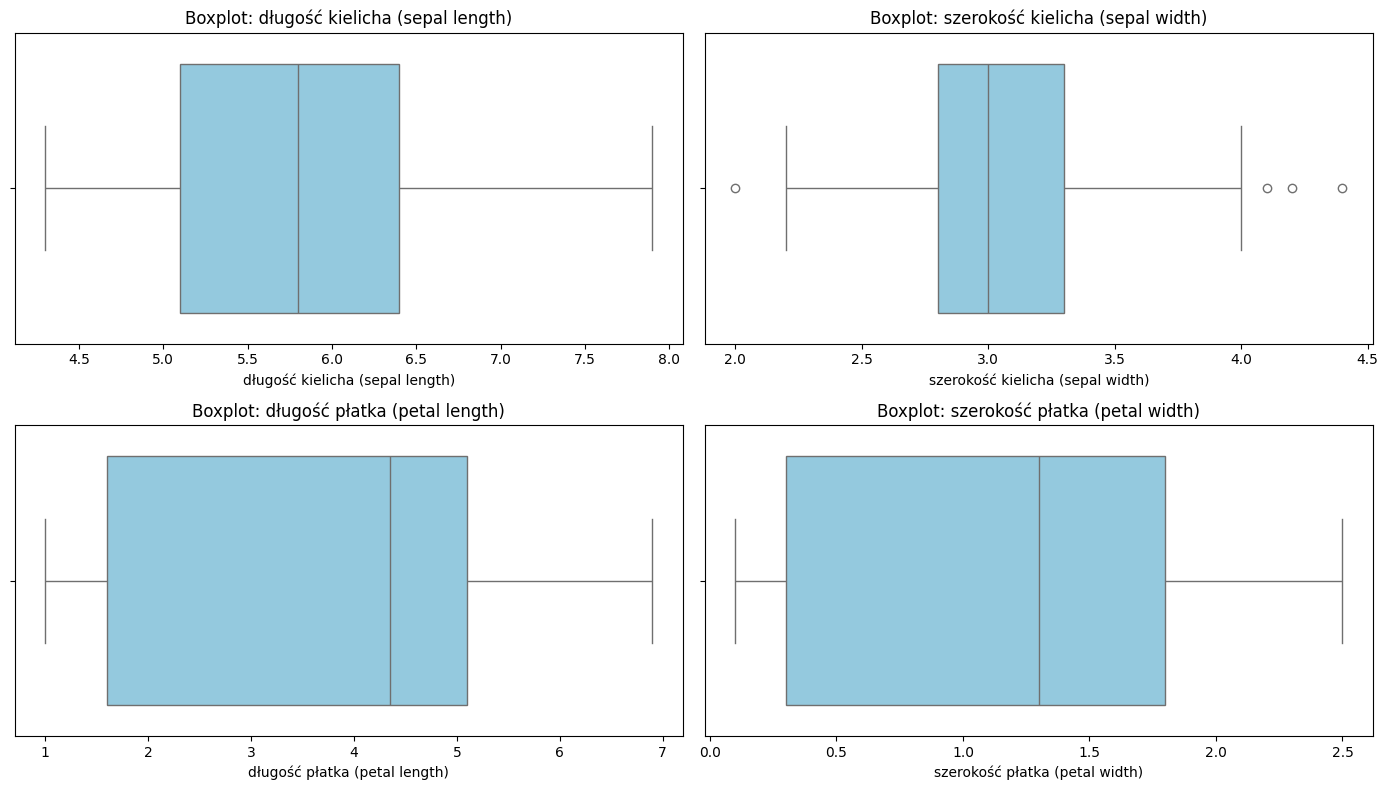

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in df.columns if df[col].dtype != 'object']
plt.figure(figsize=(14, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[feature], color='skyblue')
    plt.title(f'Boxplot: {feature}')
plt.tight_layout()
plt.show()

**Identyfikacja wartości odstających metodą IQR**

In [44]:
outliers = {}
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_rows = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outliers[feature] = outlier_rows.shape[0]
    print(f"{feature}: liczba wartości odstających = {outlier_rows.shape[0]}")

print("\nPodsumowanie liczby wartości odstających dla każdej cechy:")
print(outliers)

długość kielicha (sepal length): liczba wartości odstających = 0
szerokość kielicha (sepal width): liczba wartości odstających = 4
długość płatka (petal length): liczba wartości odstających = 0
szerokość płatka (petal width): liczba wartości odstających = 0

Podsumowanie liczby wartości odstających dla każdej cechy:
{'długość kielicha (sepal length)': 0, 'szerokość kielicha (sepal width)': 4, 'długość płatka (petal length)': 0, 'szerokość płatka (petal width)': 0}


**Komentarz:**

Wartości odstające zostały zidentyfikowane na podstawie wykresów pudełkowych oraz metody IQR. W przypadku zbioru danych Iris liczba wartości odstających jest niewielka i nie powinna znacząco wpływać na dalszą analizę. Warto jednak pamiętać o ich obecności przy budowie modeli predykcyjnych.

## Podsumowanie analizy

W przeprowadzonej eksploracyjnej analizie danych (EDA) zbioru Iris:

- Dane nie zawierają brakujących wartości, co pozwala na bezpośrednią analizę i modelowanie.
- Rozkłady cech liczbowych są zróżnicowane: niektóre są symetryczne, inne wykazują skośność. Wartości odstające występują sporadycznie i nie dominują w zbiorze.
- Analiza relacji między zmiennymi wykazała silną korelację między długością i szerokością płatka, co może być istotne przy budowie modeli predykcyjnych.
- Wykresy rozrzutu (pairplot) pokazują, że klasy irysów są dobrze rozdzielone w przestrzeni cech, szczególnie dla cech płatków.
- Wartości odstające zostały zidentyfikowane, ale ich liczba jest niewielka i nie powinny znacząco wpływać na dalszą analizę.

**Wnioski końcowe:**
Zbiór danych Iris jest dobrze przygotowany do dalszych analiz i modelowania. Wyraźna separacja klas oraz silne zależności między niektórymi cechami sugerują, że można uzyskać wysoką skuteczność klasyfikacji przy użyciu prostych modeli. Zaleca się dalszą analizę z wykorzystaniem algorytmów uczenia maszynowego.